In [2]:
import numpy as np


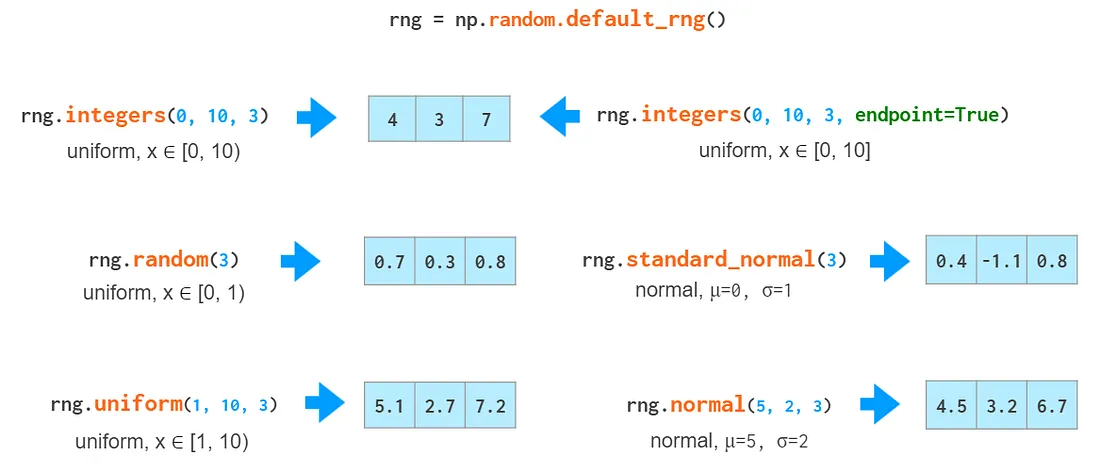 

In [3]:
A = np.array([1,2,3])
B = np.array([2,3,4])
print(A+B, A*B)

[3 5 7] [ 2  6 12]


Нампай масиви швидші для одного типу даних, та якщо можна векторизувати масив 
Звичайний список швидший для видалення останньго елемента
Список для перетворення в масив має бути однорідний інакше тип буде object

часто виникає потреба створити масив за формою як попередній але з нулів.(або інших елементів)
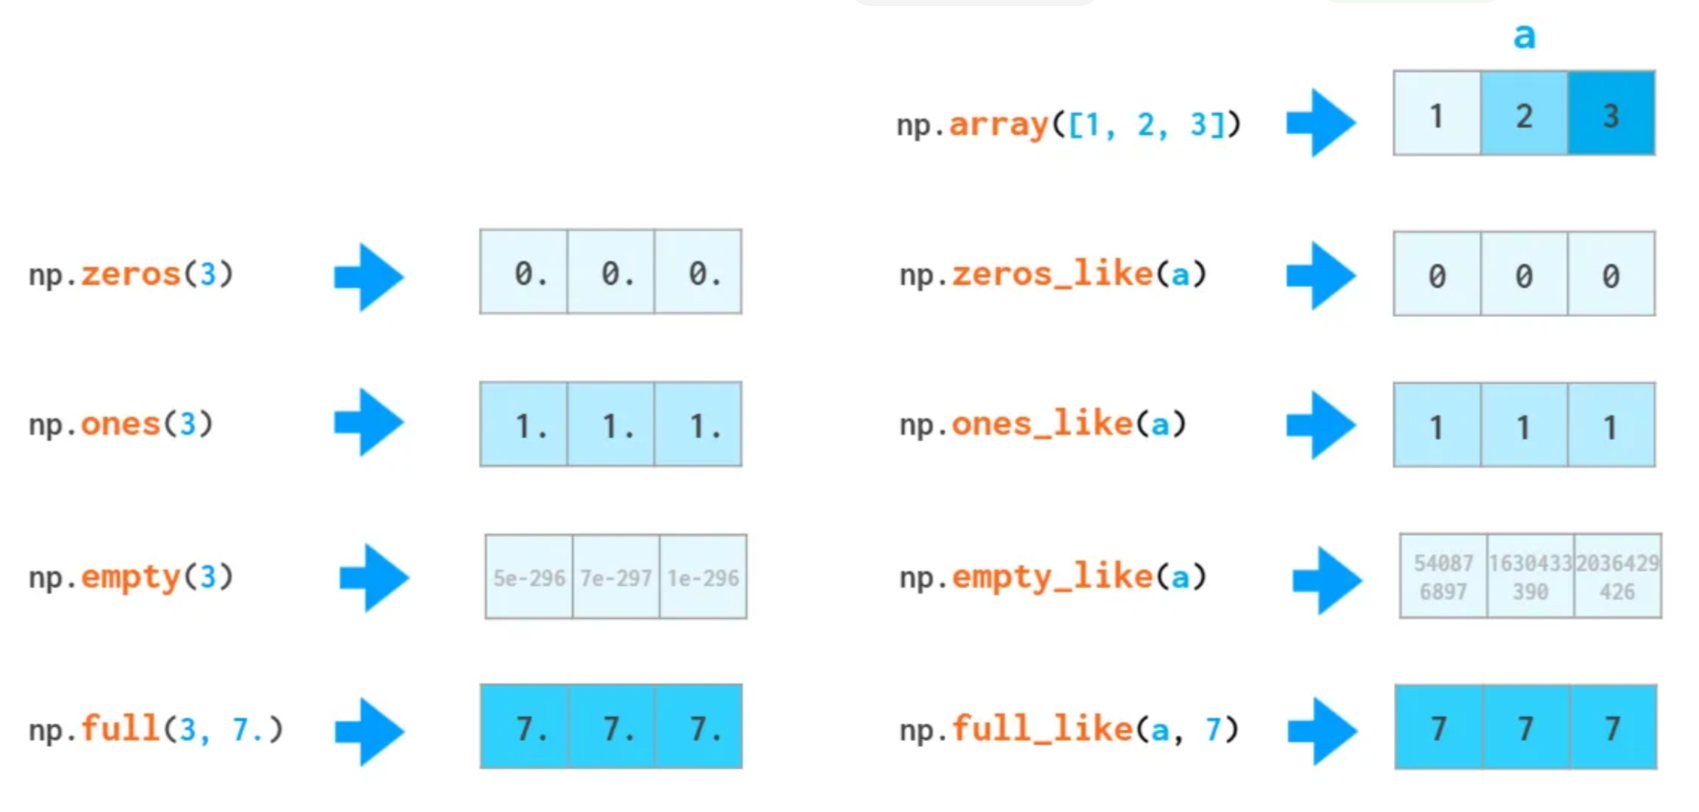

In [10]:
a = np.zeros(3, float)
c = np.zeros_like(a, int)
c

array([0, 0, 0])

Для монотонних послідовностей.
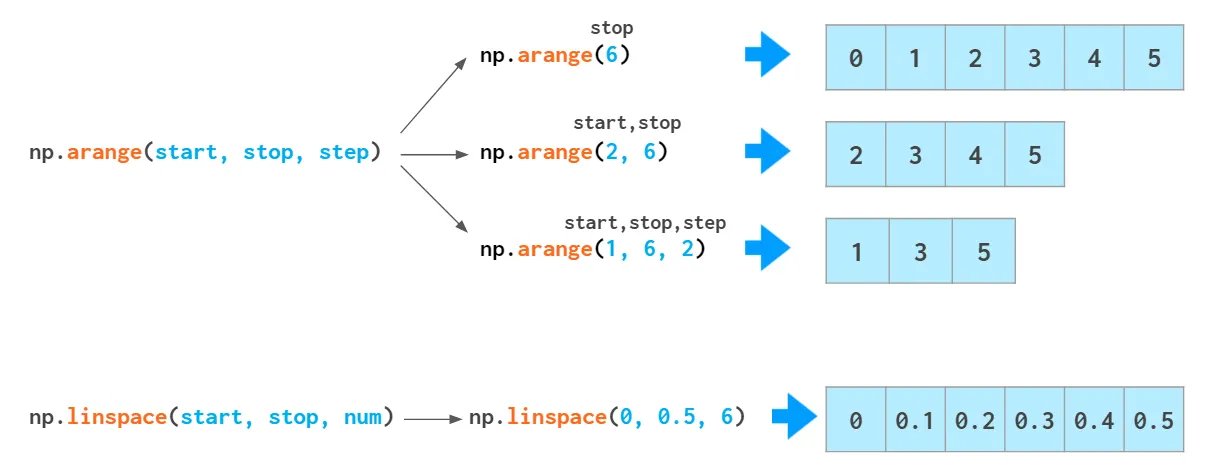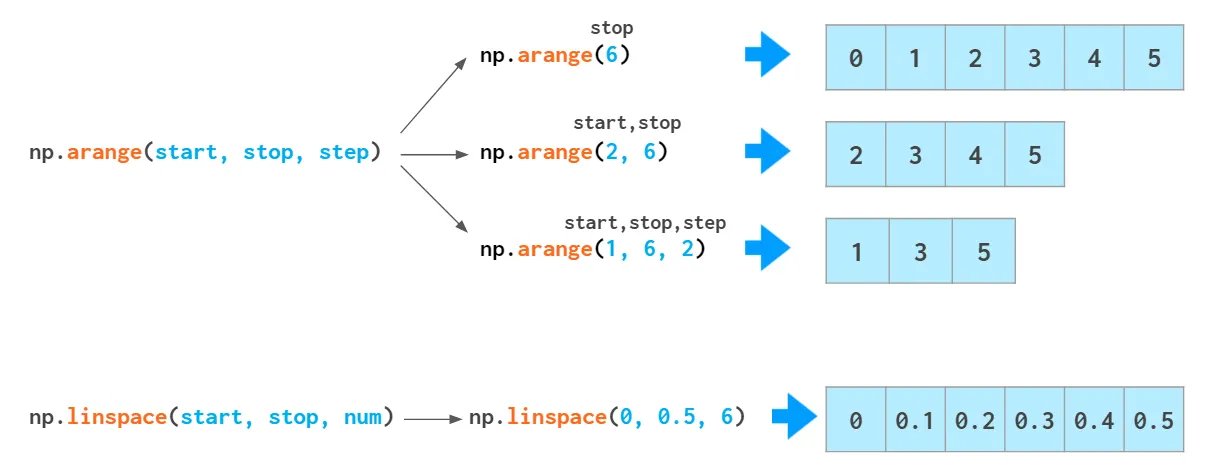

In [13]:
a = np.arange(3,6,0.1)
a

array([3. , 3.1, 3.2, 3.3, 3.4, 3.5, 3.6, 3.7, 3.8, 3.9, 4. , 4.1, 4.2,
       4.3, 4.4, 4.5, 4.6, 4.7, 4.8, 4.9, 5. , 5.1, 5.2, 5.3, 5.4, 5.5,
       5.6, 5.7, 5.8, 5.9])

In [15]:
a = np.arange(1,6)
print(a[2:4], a[-2:], a[::2], a[[1,2,3]])

[3 4] [4 5] [1 3 5] [2 3 4]


### Копіювання

In [21]:
a = [1,2,3]
b = a #не копія а просто інше імя
print(b)
c = a[:] # copy
a = np.arange(1,5)
b = a # no copy
d = a.copy()
c = a[:] # no copy

print(b)

[1, 2, 3]
[1 2 3 4]


In [32]:
#Булеве індексування 
a = np.arange(1,10)
a[(a >= 5) & (a>=6)] = 0
print(a)
print(np.all(a>5), a[a>5], np.any(a> 5), b)

[1 2 3 4 5 0 0 0 0]
False [] False 0


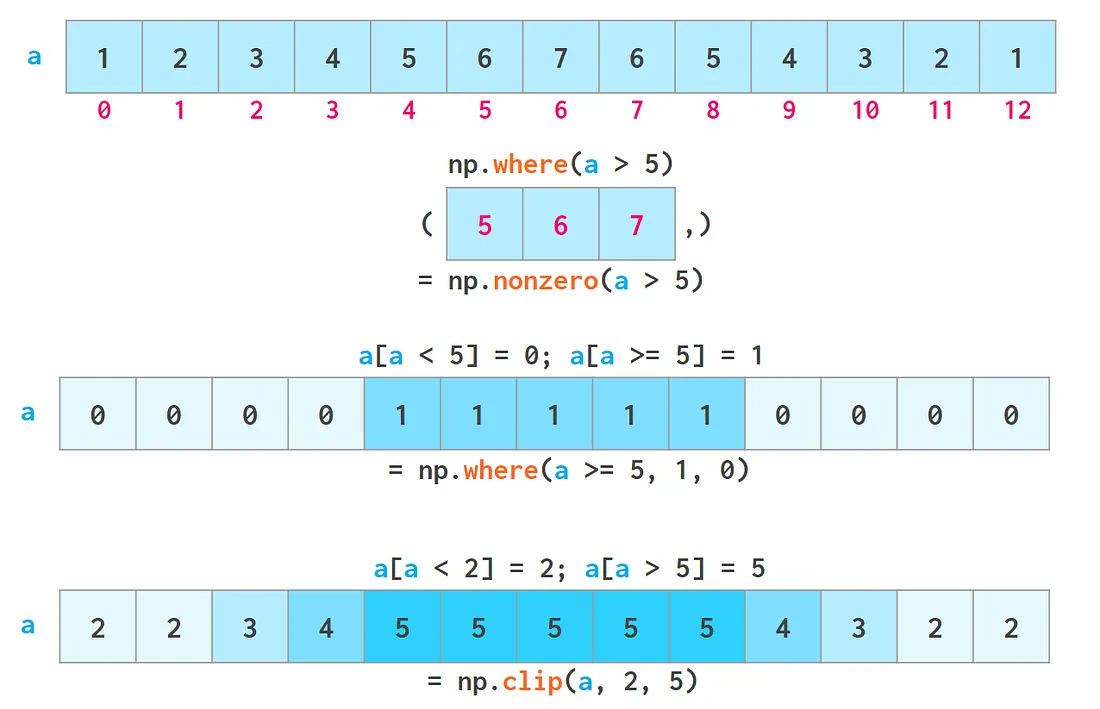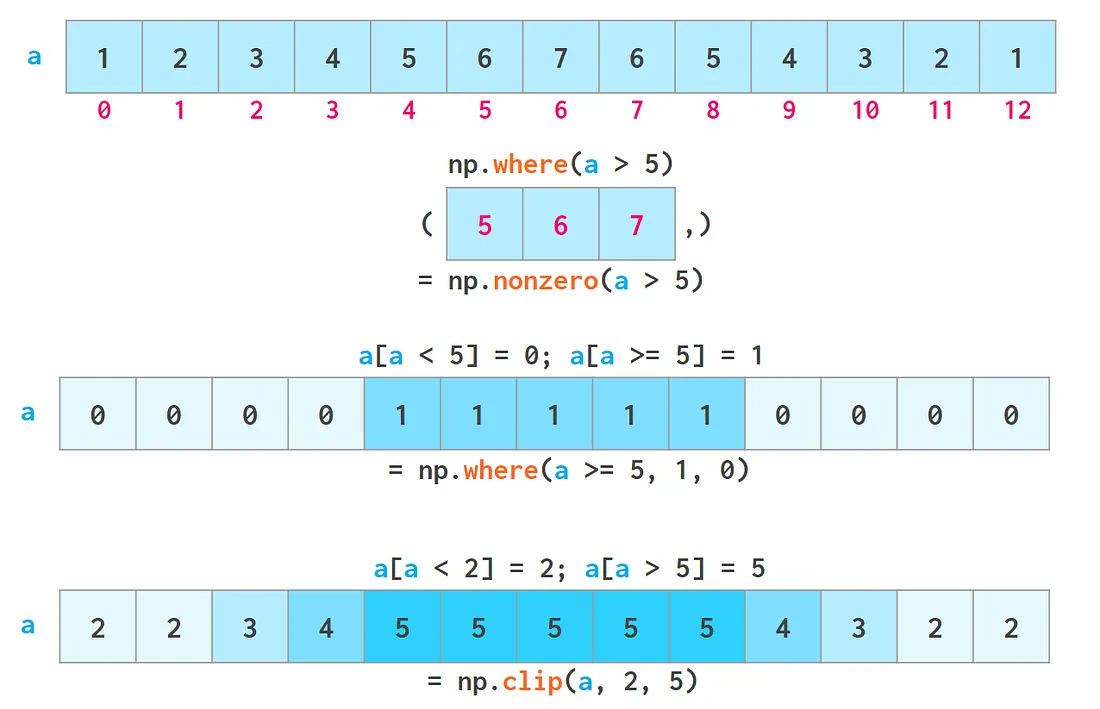
np.where повертає кортеж

In [39]:
a = np.arange(1,10)
print(np.where(a>5), np.nonzero(a>5))
print(np.clip(a,2,5))
np.where(a >=5, 1, 0)

(array([5, 6, 7, 8]),) (array([5, 6, 7, 8]),)
[2 2 3 4 5 5 5 5 5]


array([0, 0, 0, 0, 1, 1, 1, 1, 1])

### Векторні операції

In [3]:
#Арифметика
a = np.array([1,2])
b = 3
a*b #і так само всі решта


array([3, 6])

## Арифметика
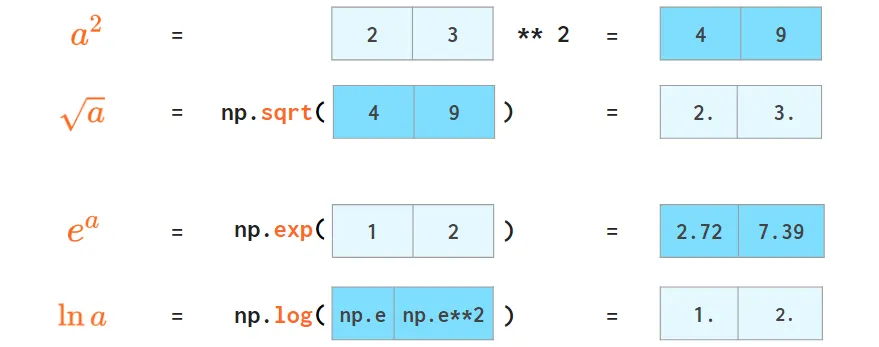
## Скаляри 
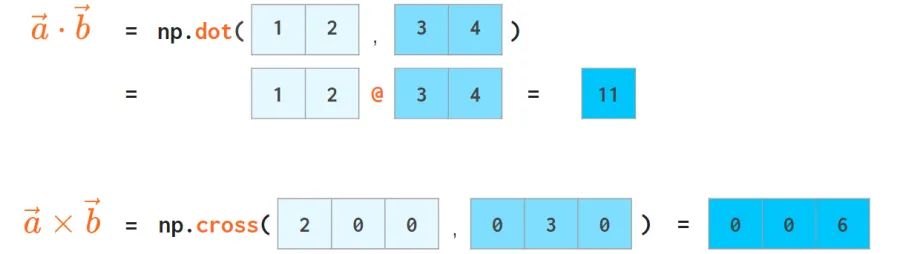
## Тригонометрія
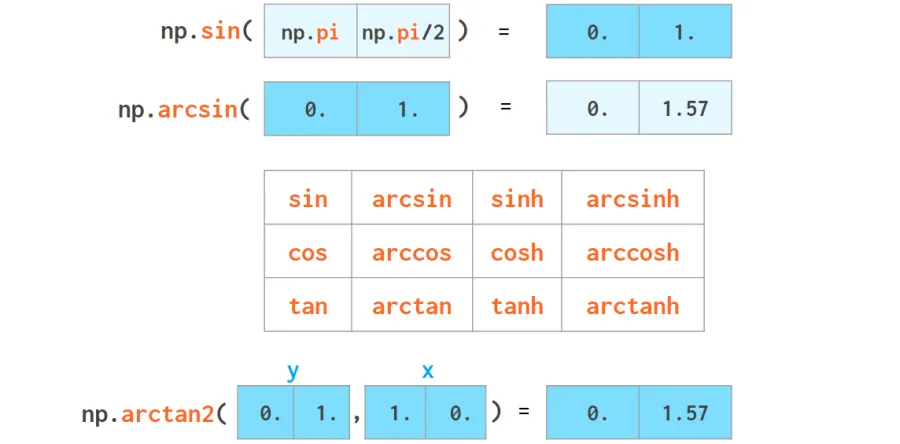

##  Округлення
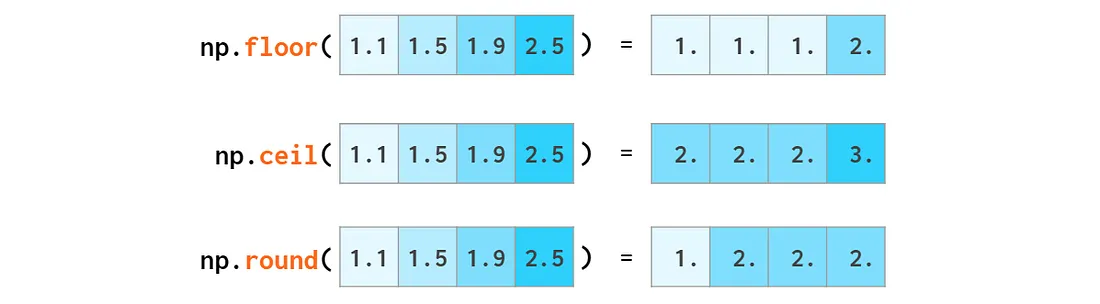
## Статистика базова
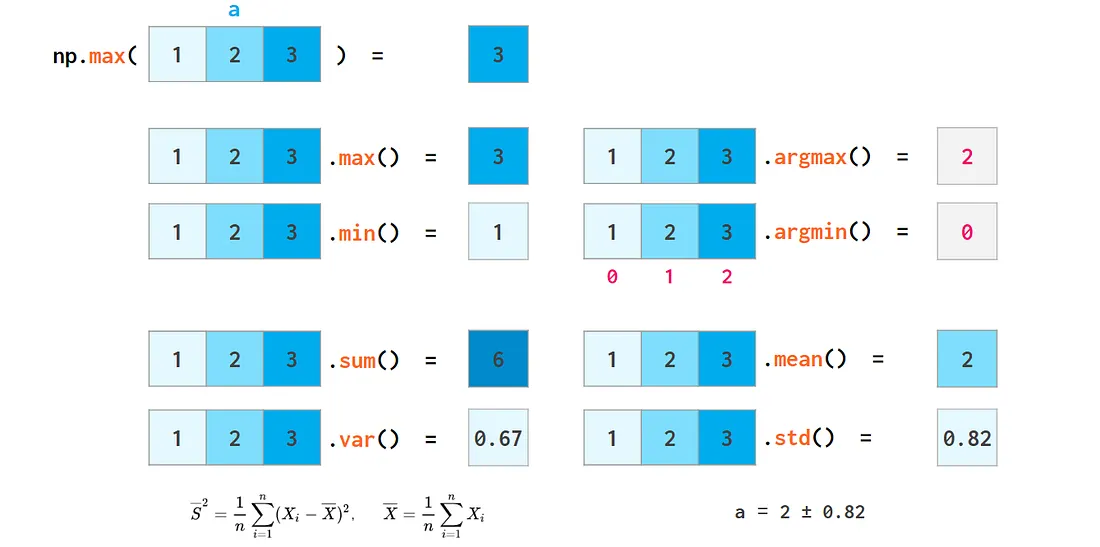

# 🧠 Конспект: Оптимізація та пошук у NumPy

## 1. Порівняльна таблиця: Python List vs. NumPy Array

| Операція | Python List | NumPy Array | Коментар |
| :--- | :--- | :--- | :--- |
| **Пошук (`index` / `where`)** | $O(n)$ | $O(n)$ | NumPy швидший завдяки C-реалізації, але має "векторизований оверхед". |
| **Додавання в кінець** | $O(1)^*$ | $O(n)$ | **NumPy програє**: він мусить перестворити весь масив у RAM. |
| **Сортування** | $O(n \log n)$ | $O(n \log n)$ | Python: Timsort. NumPy: Quicksort/Mergesort. |
| **Реверс** | $O(n)$ | **$O(1)$** | **NumPy виграє**: робить це миттєво через зміну кроку читання (strides). |

*\* Амортизована складність.*

---

## 2. Проблема пошуку та "Векторизований оверхед"

### Чому `np.where(a == x)` буває повільним?
Команда `np.where` — це **повне сканування**. 
1. **Проблема:** NumPy спочатку створює в пам'яті тимчасовий булевий масив (маску) для *всіх* елементів, навіть якщо потрібне число стоїть першим.
2. **Результат:** Відсутність "раннього виходу" (early exit).

### Швидкі альтернативи:
* **Для несортованих даних (пошук один раз):**
  * `next((i for i, v in enumerate(arr) if v == x), -1)` — швидше для "раннього виходу" в маленьких масивах.
  * **Numba:** Найкращий варіант. Компілює цикл у машинний код, дозволяючи зупинити пошук одразу при знаходженні.
* **Для сортованих даних:**
  * `np.searchsorted(a, x)` — складність **$O(\log n)$**. 
  * *Нюанс:* Сортування коштує $O(n \log n)$, тому виправдане лише для багаторазових пошуків в одному масиві.

---

## 3. Пастка Floating Point (Плаваюча кома)

У моделюванні $0.1 + 0.2 \neq 0.3$ через особливості стандарту **IEEE 754**.

### Порівняння з допуском:
* **`np.allclose(a, b, atol, rtol)`**: 
  * Формула: $|a - b| \le (atol + rtol \cdot |b|)$
  * **Проблема:** Не є транзитивною. Через вплив $|b|$ може вийти, що `allclose(a, b)` — `True`, а `allclose(b, a)` — `False`.
* **`math.isclose`**: Більш математично коректна для скалярів, не робить припущень про "типовий" масштаб чисел.

> **Важливо:** Ніколи не використовуй `==` для `float`. Завжди визначай "епсилон" (допуск), виходячи з масштабу даних (наприклад, $10^{-9}$ для секунд або $10^{-17}$ для наносекунд).

---

## 4. Ключові висновки для моделювання

1. **Hashtables ($O(1)$):** Якщо потрібно миттєво знаходити елементи, використовуй `dict` або `set`, але враховуй великі витрати RAM.
2. **Zero-copy:** Операція `a[::-1]` у NumPy не копіює дані, а лише створює "вигляд" (**view**). Це найшвидший спосіб обробки великих масивів.
3. **Бессель та ddof:** При обчисленні дисперсії пам'ятай про корекцію Бесселя. Для малих вибірок вона суттєва ($ddof=1$ для незміщеної оцінки).

### 2D Matrix
np.vstack(a,b) #додає масив вертикально якщо однакова ширина
np.hstack(a,b) #додає масив горизонтально якщо однакова висота
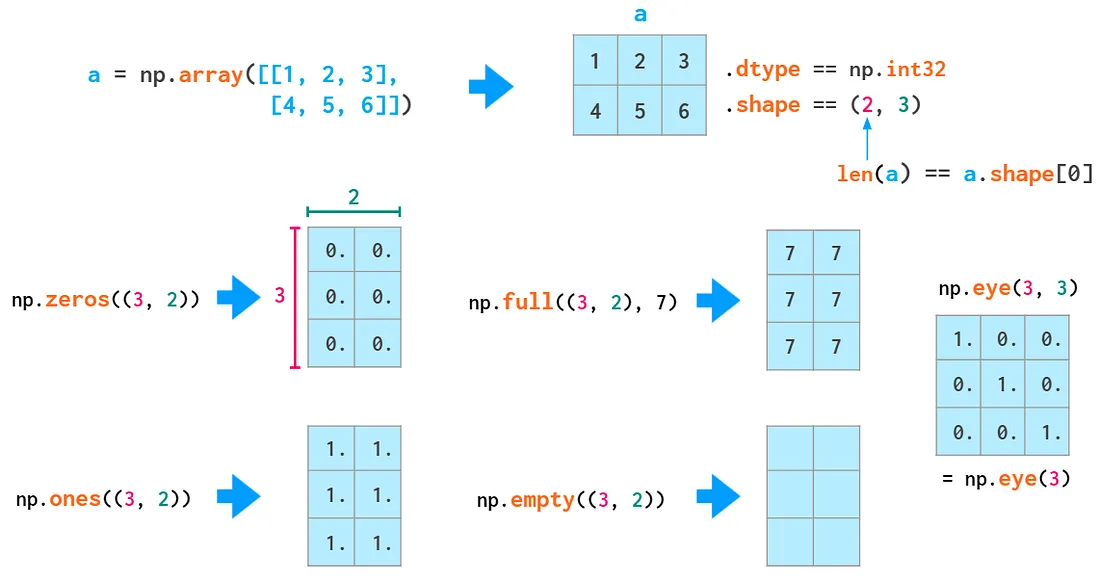 

In [7]:
import numpy as np
a2_3 = np.array([[1,2,3],[1,2,3]])
a2_3
a2_2 = np.array([[2,2],[3,3]])
a3_2 = np.full((3,2),5)



#### Індексуання


In [46]:
m = np.arange(1,26).reshape(5,5)
m

array([[ 1,  2,  3,  4,  5],
       [ 6,  7,  8,  9, 10],
       [11, 12, 13, 14, 15],
       [16, 17, 18, 19, 20],
       [21, 22, 23, 24, 25]])

In [47]:
'''#Виріжте з матриці центральний блок розміром $3 \times 3$ (числа від 7 до 19).
m[1:4,1:4]
#Виберіть кожен другий елемент у кожному другому рядку, починаючи з першого (індекс 0).
m[::2,0::2]
#кути
m[0::4,0::4]
#рамка з нулів
m[0:,-1] = 0
m[0:,0] = 0
m[0,0:] = 0
m[-1,0:] = 0
m'''
#Вправа 5: "Логічний фільтр"
mask = (m > 10) & (m % 2 == 0)
print(m[mask] * -1)

[-12 -14 -16 -18 -20 -22 -24]


#### Аргумент осі де axis=0 стовпці, axis=1 рядки
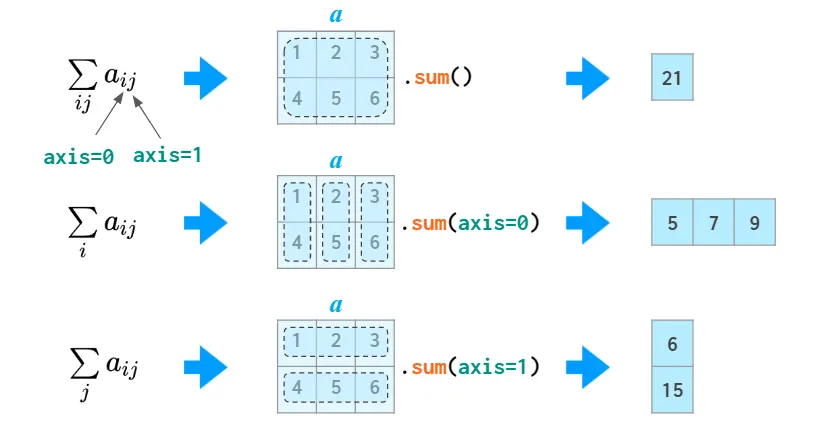

### Broadcasting розтягування

In [59]:
'''rng = np.random.default_rng()
a = rng.integers(0,10,[3,3])
b = rng.integers(0,2,3)'''

print(a,b)
a*b
a@b
#d = np.array([1,0])
#a@d - ValueError

[[5 5 7]
 [0 4 0]
 [5 1 7]] [1 0 0]


ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 2 is different from 3)

### Вектори-рядки та вектори-стовпці

In [14]:
#поворот точки(1,0) на 45градусів
import numpy as np
z = 1 + 0j  # Наша точка на осі Real

phi = np.pi / 4  # 45 градусів у радіанах
rotation = np.exp(1j * phi)

rotated = z * rotation

print(f"Оригінал: {z}")
print(f"Після повороту: {rotated}")
# Очікуємо приблизно (0.707 + 0.707j), бо cos(45) = sin(45) = sqrt(2)/2
print(f"Дійсна частина: {rotated.real:.3f}")
print(f"Уявна частина: {rotated.imag:.3f}")

Оригінал: (1+0j)
Після повороту: (0.7071067811865476+0.7071067811865475j)
Дійсна частина: 0.707
Уявна частина: 0.707


In [ ]:
safsdfdsafs